In [69]:
#scikit learn implementation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
np.set_printoptions(precision = 2, suppress=True)

In [30]:
x_train = np.array([[7.2, 12.8, 45.3, 22.1, 51.7, 9.4, 33.6, 18.9, 57.2, 28.4, 41.0, 14.6, 36.8, 24.3, 49.5, 11.1, 30.2, 55.9, 20.7, 43.8, 8.3, 26.5, 52.4, 16.2, 38.9, 47.1, 13.5, 34.7, 21.4, 58.6, 10.8, 44.2, 29.6, 17.3, 53.1, 25.8, 40.4, 12.0, 48.7, 31.9], [42.1, 8.5, 31.7, 55.2, 19.4, 47.8, 3.2, 38.6, 26.1, 12.9, 51.5, 34.0, 7.7, 44.3, 22.8, 58.1, 15.6, 40.9, 29.4, 5.1, 36.2, 49.7, 11.3, 53.8, 24.5, 17.0, 45.6, 32.3, 9.8, 41.4, 27.6, 20.2, 56.4, 13.7, 37.5, 2.4, 50.3, 30.8, 23.1, 46.9]])
y_train = np.array([24.1, 51.3, 194.4, 60.2, 235.0, 30.1, 155.5, 66.7, 231.9, 128.4, 137.2, 55.7, 170.3, 79.4, 213.4, 27.9, 133.6, 200.5, 74.7, 205.2, 29.3, 74.9, 244.7, 44.2, 165.4, 217.5, 44.5, 141.4, 96.5, 224.9, 40.7, 197.8, 91.7, 71.4, 214.2, 116.4, 156.9, 46.1, 209.7, 132.2])

print(f"x train: {x_train.shape}, y train: {y_train.shape}")

x train: (2, 40), y train: (40,)


In [31]:
x_new_train = np.array([x_train[0, :], x_train[1, :], x_train[0, :] * x_train[1, :], x_train[0, :] * (x_train[1, :] ** 2)])
x_new_train = x_new_train.T


In [33]:
# z scale normalization
scalar = StandardScaler()
x_norm = scalar.fit_transform(x_new_train)
print(f"mean: {scalar.mean_}, sigma: {scalar.scale_}")
print(f"Range before normalization: {np.ptp(x_new_train, axis=0)}")
print(f"Range after normalization: {np.ptp(x_norm, axis=0)}")

mean: [   31.15    30.64   898.19 33503.6 ], sigma: [   15.62    16.34   642.64 32096.59]
Range before normalization: [    51.4      55.7    2364.12 108593.64]
Range after normalization: [3.29 3.41 3.68 3.38]


In [42]:
sgdr = SGDRegressor(max_iter=10000)
sgdr.fit(x_norm, y_train)
print(f"no. of iterations: {sgdr.n_iter_}, total weights update: {sgdr.t_}")
print(f"w: {sgdr.coef_}, b: {sgdr.intercept_}")
print(f"Accuracy: {sgdr.score(x_norm, y_train)*100:.2f}")

no. of iterations: 1741, total weights update: 69641.0
w: [ 73.59  -1.95  -0.48 -13.01], b: [125.9]
Accuracy: 99.09


In [43]:
predict_y = sgdr.predict(x_norm)

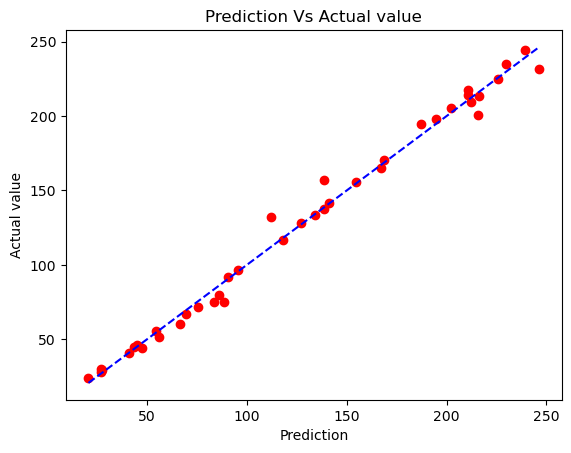

In [47]:
# prediction vs actual value plot
plt.title("Prediction Vs Actual value")
plt.xlabel("Prediction")
plt.ylabel("Actual value")
plt.scatter(predict_y, y_train, marker="o", color="r")
lo = min(min(predict_y), min(y_train))
hi = max(max(predict_y), max(y_train))

plt.plot([lo, hi], [lo, hi], color="b", linestyle="--")
plt.show()

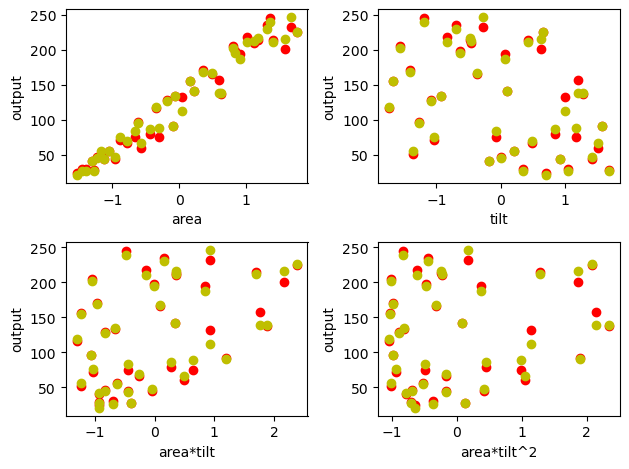

In [68]:
# prediction plot against each feature
fig, ax = plt.subplots(2, 2)

ax[0, 0].scatter(x_norm[:, 0], y_train, color="r")
ax[0, 0].scatter(x_norm[:, 0], predict_y, color="y")
ax[0, 0].set_xlabel("area")
ax[0, 0].set_ylabel("output")

ax[0, 1].scatter(x_norm[:, 1], y_train, color="r")
ax[0, 1].scatter(x_norm[:, 1], predict_y, color="y")
ax[0, 1].set_xlabel("tilt")
ax[0, 1].set_ylabel("output")

ax[1, 0].scatter(x_norm[:, 2], y_train, color="r")
ax[1, 0].scatter(x_norm[:, 2], predict_y, color="y")
ax[1, 0].set_xlabel("area*tilt")
ax[1, 0].set_ylabel("output")

ax[1, 1].scatter(x_norm[:, 3], y_train, color="r")
ax[1, 1].scatter(x_norm[:, 3], predict_y, color="y")
ax[1, 1].set_xlabel("area*tilt^2")
ax[1, 1].set_ylabel("output")

plt.tight_layout()
plt.show()

In [70]:
# scikit learn prediction
value_z_scaled = scalar.transform(np.array([[35, 12, 35*12, 35*(12**2)]]))
print("Final price: ", end="")
print(sgdr.predict(value_z_scaled))

Final price: [158.17]
